# Logistic regression

This notebook creates the fixed stratified 60/40 development split and fits a logistic regression using training-only preprocessing, feature selection and cutoff selection.

## Load and verify the cleaned data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import (
    brier_score_loss,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    accuracy_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 123456
VALIDATION_SHARE = 0.40
TARGET_COLUMN = "Class"
ROW_ID_COLUMN = "ROW_ID"
SPLIT_COLUMN = "SPLIT"
SPLIT_CODES = {"training": 0, "validation": 1}
PCA_COLUMNS = [f"V{i}" for i in range(1, 29)]
FEATURE_COLUMNS = PCA_COLUMNS + ["Amount"]
EXPECTED_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]
DATA_PATH = Path("../data/processed/fraud_clean.csv")
MODELING_DATA_PATH = Path("../data/processed/fraud_modeling.csv")
LOGISTIC_PREDICTIONS_PATH = Path(
    "../data/processed/logistic_model_predictions.csv"
)

assert DATA_PATH.exists(), f"Missing input file: {DATA_PATH}"

In [2]:
# load the cleaned transaction data
fraud_data = pd.read_csv(DATA_PATH)
fraud_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0
1,-0.6079,1.0313,1.7404,1.2321,0.4186,0.1192,0.8509,-0.1763,-0.2435,0.1485,-0.3870,0.3983,0.4819,-0.3654,0.2355,-1.3478,0.5046,-0.7984,0.7597,0.2543,-0.0873,0.2583,-0.2648,0.1183,0.1735,-0.2170,0.0943,-0.0330,14.8000,0
2,1.3864,-0.7942,0.7782,-0.8647,-1.0641,0.3513,-1.1915,0.0527,-0.3044,0.5765,-1.6311,0.0426,2.0479,-0.7393,1.4562,-0.2720,-0.9320,1.9265,-0.6599,-0.2730,-0.2287,-0.1235,-0.1310,-0.9297,0.1814,1.1949,0.0005,0.0199,30.9000,0
3,1.1543,0.2655,0.3849,0.5750,-0.2175,-0.3915,-0.0815,0.0628,-0.2606,-0.1617,2.0529,1.1308,0.1895,-0.0708,0.6193,0.3186,0.0902,-0.3315,-0.3447,-0.0996,-0.1932,-0.5577,0.1695,0.1869,0.0893,0.0936,-0.0096,0.0197,2.6700,0
4,-0.7734,0.8531,0.8183,-0.2361,0.8035,-1.4387,0.7995,-0.0080,-0.7611,-1.0445,1.5041,-0.2916,-1.6154,-0.6653,-0.2930,0.8031,0.4621,0.8346,-0.6518,-0.1009,0.0354,-0.1169,-0.1789,0.4002,-0.0262,0.1652,0.0278,0.1330,0.7600,0


In [3]:
fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9942 entries, 0 to 9941
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      9942 non-null   float64
 1   V2      9942 non-null   float64
 2   V3      9942 non-null   float64
 3   V4      9942 non-null   float64
 4   V5      9942 non-null   float64
 5   V6      9942 non-null   float64
 6   V7      9942 non-null   float64
 7   V8      9942 non-null   float64
 8   V9      9942 non-null   float64
 9   V10     9942 non-null   float64
 10  V11     9942 non-null   float64
 11  V12     9942 non-null   float64
 12  V13     9942 non-null   float64
 13  V14     9942 non-null   float64
 14  V15     9942 non-null   float64
 15  V16     9942 non-null   float64
 16  V17     9942 non-null   float64
 17  V18     9942 non-null   float64
 18  V19     9942 non-null   float64
 19  V20     9942 non-null   float64
 20  V21     9942 non-null   float64
 21  V22     9942 non-null   float64
 22  

In [4]:
# verify the cleaned input before splitting
input_summary = pd.Series({
    "rows": len(fraud_data),
    "columns": fraud_data.shape[1],
    "predictors": len(FEATURE_COLUMNS),
    "normal transactions": int(fraud_data[TARGET_COLUMN].eq(0).sum()),
    "fraudulent transactions": int(fraud_data[TARGET_COLUMN].eq(1).sum()),
    "fraud rate": fraud_data[TARGET_COLUMN].mean(),
    "missing values": int(fraud_data.isna().sum().sum()),
    "infinite predictor values": int(np.isinf(fraud_data[FEATURE_COLUMNS]).sum().sum()),
    "exact duplicate rows": int(fraud_data.duplicated().sum()),
}, name="value").to_frame()
display(input_summary)

assert fraud_data.shape == (9_942, 30)
assert fraud_data.columns.tolist() == EXPECTED_COLUMNS
assert fraud_data.select_dtypes(include=np.number).shape[1] == 30
assert set(fraud_data[TARGET_COLUMN].unique()) == {0, 1}
assert fraud_data.isna().sum().sum() == 0
assert np.isfinite(fraud_data[FEATURE_COLUMNS].to_numpy()).all()
assert not fraud_data.duplicated().any()

,value
rows,"9,942.0000"
columns,30.0000
predictors,29.0000
normal transactions,"9,469.0000"
fraudulent transactions,473.0000
fraud rate,0.0476
missing values,0.0000
infinite predictor values,0.0000
exact duplicate rows,0.0000


## Create the fixed development split

In [5]:
# split row indexes while preserving the fraud rate
training_index, validation_index = train_test_split(
    fraud_data.index,
    test_size=VALIDATION_SHARE,
    random_state=RANDOM_STATE,
    stratify=fraud_data[TARGET_COLUMN],
)

modeling_data = fraud_data.copy()
modeling_data.insert(0, ROW_ID_COLUMN, np.arange(len(modeling_data)))
modeling_data[SPLIT_COLUMN] = -1
modeling_data.loc[training_index, SPLIT_COLUMN] = SPLIT_CODES["training"]
modeling_data.loc[validation_index, SPLIT_COLUMN] = SPLIT_CODES["validation"]
modeling_data[SPLIT_COLUMN] = modeling_data[SPLIT_COLUMN].astype("int8")

split_summary = (
    modeling_data.groupby(SPLIT_COLUMN)[TARGET_COLUMN]
    .agg(transactions="size", frauds="sum", fraud_rate="mean")
    .rename(index={value: label for label, value in SPLIT_CODES.items()})
)
split_summary["sample_share"] = split_summary["transactions"] / len(modeling_data)
split_summary

,transactions,frauds,fraud_rate,sample_share
SPLIT,,,,
training,5965,284,0.0476,0.6000
validation,3977,189,0.0475,0.4000


In [6]:
# confirm that the split is complete and disjoint
training_ids = set(modeling_data.loc[training_index, ROW_ID_COLUMN])
validation_ids = set(modeling_data.loc[validation_index, ROW_ID_COLUMN])
split_checks = pd.Series({
    "all rows assigned": modeling_data[SPLIT_COLUMN].isin(SPLIT_CODES.values()).all(),
    "row ids are unique": modeling_data[ROW_ID_COLUMN].is_unique,
    "samples are disjoint": training_ids.isdisjoint(validation_ids),
    "samples are exhaustive": len(training_ids | validation_ids) == len(modeling_data),
    "both samples contain both classes": (
        modeling_data.groupby(SPLIT_COLUMN)[TARGET_COLUMN].nunique().eq(2).all()
    ),
}, name="passed").to_frame()
display(split_checks)
assert split_checks["passed"].all()

MODELING_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
modeling_data.to_csv(MODELING_DATA_PATH, index=False)
print(f"saved {len(modeling_data):,} rows to {MODELING_DATA_PATH}")

,passed
all rows assigned,True
row ids are unique,True
samples are disjoint,True
samples are exhaustive,True
both samples contain both classes,True


saved 9,942 rows to ../data/processed/fraud_modeling.csv


## Define predictors and target

In [7]:
# separate the fixed samples without exposing validation to selection
training_data = modeling_data.loc[
    modeling_data[SPLIT_COLUMN].eq(SPLIT_CODES["training"])
].copy()
validation_data = modeling_data.loc[
    modeling_data[SPLIT_COLUMN].eq(SPLIT_CODES["validation"])
].copy()
training_target = training_data[TARGET_COLUMN].copy()
validation_target = validation_data[TARGET_COLUMN].copy()

development_summary = pd.DataFrame({
    "sample": ["training", "validation"],
    "transactions": [len(training_data), len(validation_data)],
    "frauds": [int(training_target.sum()), int(validation_target.sum())],
    "fraud_rate": [training_target.mean(), validation_target.mean()],
}).set_index("sample")
display(development_summary)

assert training_data[ROW_ID_COLUMN].is_unique
assert validation_data[ROW_ID_COLUMN].is_unique
assert set(training_data[ROW_ID_COLUMN]).isdisjoint(validation_data[ROW_ID_COLUMN])

,transactions,frauds,fraud_rate
sample,,,
training,5965,284,0.0476
validation,3977,189,0.0475


## Correlation and VIF

In [8]:
def rank_correlation_pairs(predictors):
    correlation_matrix = predictors.corr()
    upper_triangle = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    correlation_pairs = (
        correlation_matrix.where(upper_triangle)
        .stack()
        .rename("correlation")
        .to_frame()
    )
    correlation_pairs["absolute_correlation"] = correlation_pairs["correlation"].abs()
    return correlation_matrix, correlation_pairs.sort_values(
        "absolute_correlation", ascending=False
    )


def calculate_vif(predictors):
    standardized = (predictors - predictors.mean()) / predictors.std(ddof=0)
    design_matrix = add_constant(standardized, has_constant="add")
    vif_values = [
        variance_inflation_factor(design_matrix.to_numpy(), column_index)
        for column_index in range(1, design_matrix.shape[1])
    ]
    return (
        pd.DataFrame({"predictor": predictors.columns, "VIF": vif_values})
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

### Raw Amount

#### Correlation Heatmap

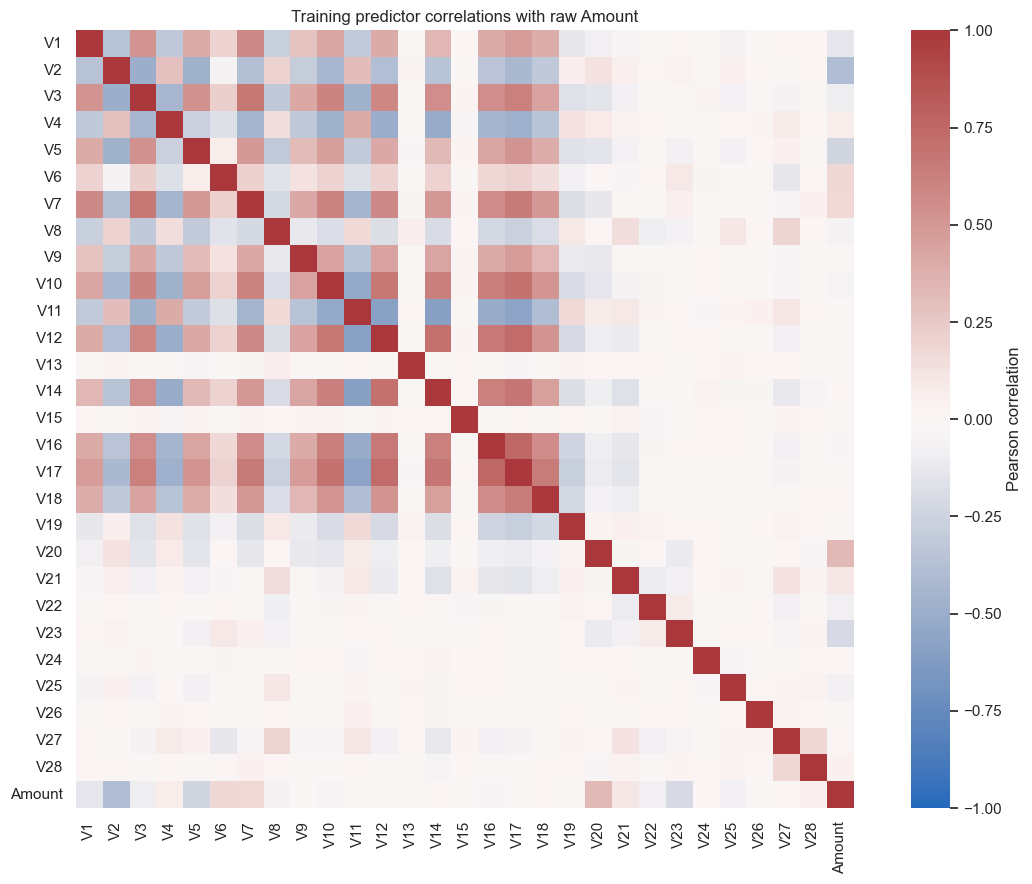

In [9]:
# calculate and plot raw amount correlations
training_predictors_raw = training_data[FEATURE_COLUMNS].copy()
raw_correlation, raw_correlation_pairs = rank_correlation_pairs(training_predictors_raw)

plt.figure(figsize=(12, 9))
sns.heatmap(
    raw_correlation,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Training predictor correlations with raw Amount")
plt.tight_layout()
plt.show()
plt.close()

#### Strongest Correlation Pairs

In [10]:
# show exact signed correlations for the strongest pairs
(
    raw_correlation_pairs.head(10)[["correlation"]]
    .rename_axis(index=["predictor_1", "predictor_2"])
)

correlation
predictor_1 predictor_2             
V16         V17               0.7502
V12         V17               0.7325
            V14               0.7103
V10         V17               0.7010
V14         V17               0.6719
V10         V12               0.6677
V3          V7                0.6651
V12         V16               0.6617
V7          V17               0.6545
V17         V18               0.6410

#### VIF Table

In [11]:
# show multivariate collinearity for every predictor
raw_vif = calculate_vif(training_predictors_raw)
raw_vif

,predictor,VIF
0,Amount,13.7888
1,V7,11.1042
2,V2,10.3666
3,V5,6.2874
4,V3,4.9645
5,V17,4.1662
6,V1,3.8762
7,V12,3.0201
8,V10,2.9859
9,V14,2.7497


### Log-transformed Amount

#### Correlation Heatmap

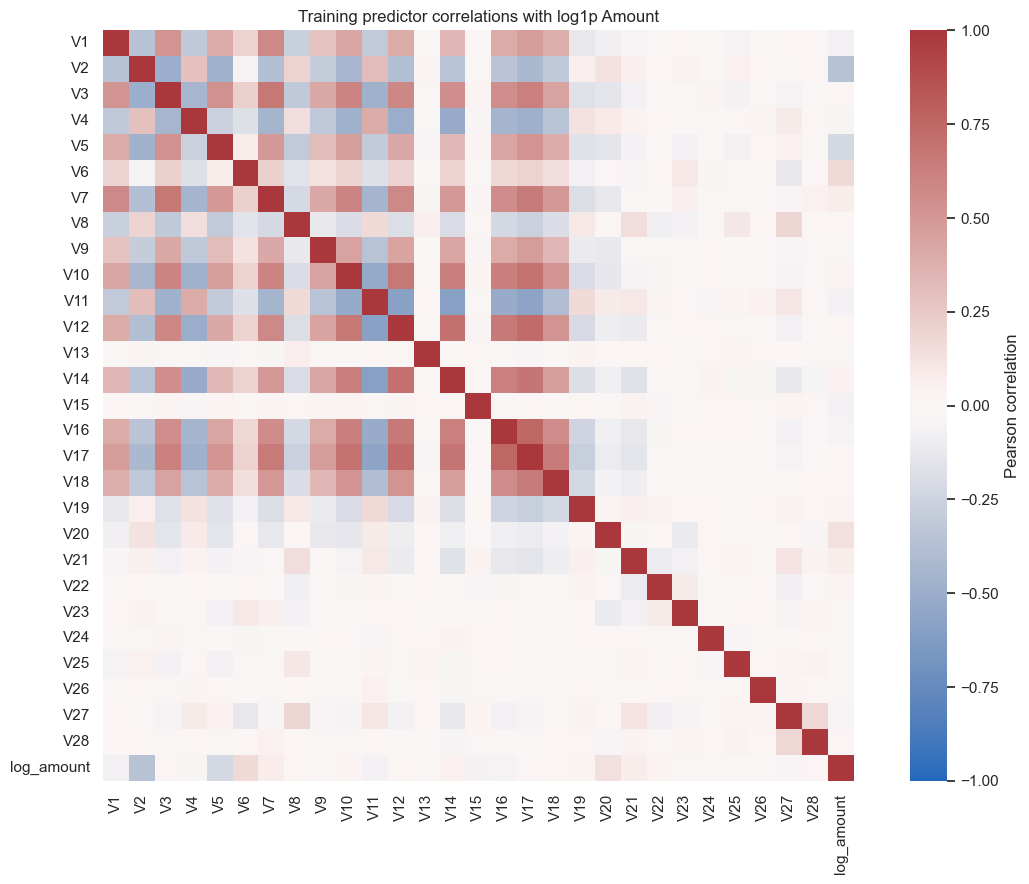

In [12]:
# calculate and plot log amount correlations
training_predictors_log = training_data[PCA_COLUMNS].copy()
training_predictors_log["log_amount"] = np.log1p(training_data["Amount"])
log_correlation, log_correlation_pairs = rank_correlation_pairs(training_predictors_log)

plt.figure(figsize=(12, 9))
sns.heatmap(
    log_correlation,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Training predictor correlations with log1p Amount")
plt.tight_layout()
plt.show()
plt.close()

#### Strongest Correlation Pairs

In [13]:
# show exact signed correlations for the strongest pairs
(
    log_correlation_pairs.head(10)[["correlation"]]
    .rename_axis(index=["predictor_1", "predictor_2"])
)

correlation
predictor_1 predictor_2             
V16         V17               0.7502
V12         V17               0.7325
            V14               0.7103
V10         V17               0.7010
V14         V17               0.6719
V10         V12               0.6677
V3          V7                0.6651
V12         V16               0.6617
V7          V17               0.6545
V17         V18               0.6410

#### VIF Table

In [14]:
# show multivariate collinearity for every predictor
log_vif = calculate_vif(training_predictors_log)
log_vif

,predictor,VIF
0,V17,4.1686
1,V12,3.0115
2,V7,2.7959
3,V14,2.7100
4,V16,2.6588
5,V10,2.5951
6,V3,2.5901
7,V2,2.2932
8,V5,2.2415
9,log_amount,1.8540


## Transform and standardize the predictors

In [15]:
# add the selected transformation to both samples
training_data["log_amount"] = np.log1p(training_data["Amount"])
validation_data["log_amount"] = np.log1p(validation_data["Amount"])

MODEL_FEATURE_COLUMNS = PCA_COLUMNS + ["log_amount"]
training_predictors = training_data[MODEL_FEATURE_COLUMNS].copy()
validation_predictors = validation_data[MODEL_FEATURE_COLUMNS].copy()

assert np.isfinite(training_predictors.to_numpy()).all()
assert np.isfinite(validation_predictors.to_numpy()).all()

The transformation reduces the skew in `Amount` and enters the full model as a candidate. It is removed during feature selection, so `Amount` does not affect the final logistic specification.

In [16]:
# learn scaling parameters from training data only
scaler = StandardScaler()
training_predictors_scaled = pd.DataFrame(
    scaler.fit_transform(training_predictors),
    columns=MODEL_FEATURE_COLUMNS,
    index=training_predictors.index,
)
validation_predictors_scaled = pd.DataFrame(
    scaler.transform(validation_predictors),
    columns=MODEL_FEATURE_COLUMNS,
    index=validation_predictors.index,
)

scaling_check = pd.Series({
    "largest absolute training mean": training_predictors_scaled.mean().abs().max(),
    "largest training standard deviation difference from one": (
        training_predictors_scaled.std(ddof=0).sub(1).abs().max()
    ),
}, name="value").to_frame()
scaling_check

,value
largest absolute training mean,0.0000
largest training standard deviation difference from one,0.0000


## Initial logistic regression

In [17]:
# fit the full model on the training sample
training_design = sm.add_constant(training_predictors_scaled, has_constant="add")
validation_design = sm.add_constant(validation_predictors_scaled, has_constant="add")

full_logit_model = sm.Logit(training_target, training_design)
full_logit_result = full_logit_model.fit(disp=False, maxiter=200)

assert full_logit_result.mle_retvals["converged"]
assert np.isfinite(full_logit_result.params).all()

### Coefficients

In [18]:
# show the fitted model estimates
coefficient_table = pd.DataFrame({
    "coefficient": full_logit_result.params,
    "standard_error": full_logit_result.bse,
    "z_statistic": full_logit_result.tvalues,
    "p_value": full_logit_result.pvalues,
})
coefficient_table

,coefficient,standard_error,z_statistic,p_value
const,-5.1139,0.2360,-21.6660,0.0000
V1,0.1764,0.2046,0.8620,0.3887
V2,-0.1241,0.1987,-0.6247,0.5321
V3,-0.3838,0.2256,-1.7015,0.0889
V4,1.2718,0.2246,5.6613,0.0000
V5,0.1378,0.2354,0.5856,0.5582
V6,-0.1905,0.2144,-0.8887,0.3742
V7,0.1822,0.2406,0.7572,0.4489
V8,-0.6907,0.1337,-5.1667,0.0000
V9,-0.2448,0.2459,-0.9955,0.3195


### Model fit

In [19]:
# retain criteria needed for later model comparison
parameter_count = len(full_logit_result.params)
observation_count = int(full_logit_result.nobs)
model_fit = pd.Series({
    "log_likelihood": full_logit_result.llf,
    "AIC": -2 * full_logit_result.llf + 2 * parameter_count,
    "BIC": -2 * full_logit_result.llf + np.log(observation_count) * parameter_count,
}, name="value").to_frame()
model_fit

,value
log_likelihood,-226.7226
AIC,513.4453
BIC,714.2552


## Backward elimination

Predictors with full-model `p < 0.10` enter the candidate model. `V13` is also reviewed as a borderline predictor just above 0.10, then the 5% retention rule is applied consistently during refitting.

In [20]:
# use a liberal screen before backward elimination
SCREENING_LEVEL = 0.10
RETENTION_LEVEL = 0.05
full_model_p_values = full_logit_result.pvalues.drop("const")

INITIAL_FEATURES = full_model_p_values.loc[
    full_model_p_values.lt(SCREENING_LEVEL)
].index.tolist()
INITIAL_FEATURES.insert(INITIAL_FEATURES.index("V14"), "V13")

screening_table = pd.DataFrame({
    "full_model_p_value": full_model_p_values.reindex(INITIAL_FEATURES),
    "selection_reason": [
        "p < 0.10" if feature != "V13" else "borderline check above 0.10"
        for feature in INITIAL_FEATURES
    ],
})
screening_table.index.name = "predictor"
display(screening_table)

,full_model_p_value,selection_reason
predictor,,
V3,0.0889,p < 0.10
V4,0.0000,p < 0.10
V8,0.0000,p < 0.10
V10,0.0040,p < 0.10
V12,0.0014,p < 0.10
V13,0.1047,borderline check above 0.10
V14,0.0000,p < 0.10
V21,0.0096,p < 0.10
V22,0.0313,p < 0.10


### Elimination path

In [21]:
# refit after removing the largest insignificant predictor
def fit_logit(features):
    design = sm.add_constant(
        training_predictors_scaled[features], has_constant="add"
    )
    model = sm.Logit(training_target, design)
    return model.fit(disp=False, maxiter=200)

initial_candidate_result = fit_logit(INITIAL_FEATURES)

without_v3_features = [
    feature for feature in INITIAL_FEATURES if feature != "V3"
]
without_v3_result = fit_logit(without_v3_features)

SELECTED_FEATURES = [
    feature for feature in without_v3_features if feature != "V13"
]
reduced_logit_result = fit_logit(SELECTED_FEATURES)

elimination_history = pd.DataFrame({
    "step": [1, 2, 3],
    "predictors": [10, 9, 8],
    "largest_p_feature": ["V3", "V13", "V23"],
    "largest_p_value": [
        initial_candidate_result.pvalues.drop("const").max(),
        without_v3_result.pvalues.drop("const").max(),
        reduced_logit_result.pvalues.drop("const").max(),
    ],
    "decision": ["remove V3", "remove V13", "stop"],
}).set_index("step")

p_value_path = pd.DataFrame({
    "full_model": full_logit_result.pvalues.reindex(INITIAL_FEATURES),
    "initial_candidates": initial_candidate_result.pvalues.reindex(INITIAL_FEATURES),
    "after_removing_V3": without_v3_result.pvalues.reindex(INITIAL_FEATURES),
    "final_model": reduced_logit_result.pvalues.reindex(INITIAL_FEATURES),
})
p_value_path.index.name = "predictor"

assert initial_candidate_result.pvalues["V3"] > RETENTION_LEVEL
assert without_v3_result.pvalues["V13"] > RETENTION_LEVEL
assert reduced_logit_result.pvalues.drop("const").lt(RETENTION_LEVEL).all()

display(elimination_history)
display(p_value_path)

,predictors,largest_p_feature,largest_p_value,decision
step,,,,
1,10,V3,0.1450,remove V3
2,9,V13,0.0887,remove V13
3,8,V23,0.0106,stop


,full_model,initial_candidates,after_removing_V3,final_model
predictor,,,,
V3,0.0889,0.1450,NaN,NaN
V4,0.0000,0.0000,0.0000,0.0000
V8,0.0000,0.0000,0.0000,0.0000
V10,0.0040,0.0000,0.0000,0.0000
V12,0.0014,0.0000,0.0000,0.0000
V13,0.1047,0.1065,0.0887,NaN
V14,0.0000,0.0000,0.0000,0.0000
V21,0.0096,0.0045,0.0037,0.0037
V22,0.0313,0.0093,0.0112,0.0091


### Final coefficients

In [22]:
# define validation inputs for the selected specification
reduced_training_design = sm.add_constant(
    training_predictors_scaled[SELECTED_FEATURES], has_constant="add"
)
reduced_validation_design = sm.add_constant(
    validation_predictors_scaled[SELECTED_FEATURES], has_constant="add"
)
reduced_logit_model = sm.Logit(training_target, reduced_training_design)

assert reduced_logit_result.mle_retvals["converged"]
assert np.isfinite(reduced_logit_result.params).all()

reduced_coefficient_table = pd.DataFrame({
    "coefficient": reduced_logit_result.params,
    "standard_error": reduced_logit_result.bse,
    "z_statistic": reduced_logit_result.tvalues,
    "p_value": reduced_logit_result.pvalues,
})
reduced_coefficient_table

,coefficient,standard_error,z_statistic,p_value
const,-5.1346,0.2076,-24.7342,0.0000
V4,1.2460,0.1701,7.3245,0.0000
V8,-0.5660,0.1084,-5.2219,0.0000
V10,-1.2493,0.2404,-5.1968,0.0000
V12,-0.9505,0.2125,-4.4718,0.0000
V14,-1.3011,0.1846,-7.0478,0.0000
V21,0.2986,0.1028,2.9048,0.0037
V22,0.4035,0.1546,2.6099,0.0091
V23,-0.1838,0.0719,-2.5559,0.0106


### Model fit

In [23]:
# compare each backward-elimination specification
def summarize_logit_fit(result):
    parameter_count = len(result.params)
    return {
        "predictors": parameter_count - 1,
        "log_likelihood": result.llf,
        "AIC": -2 * result.llf + 2 * parameter_count,
        "BIC": (
            -2 * result.llf
            + np.log(observation_count) * parameter_count
        ),
    }

model_fit_comparison = pd.DataFrame({
    "full_model": summarize_logit_fit(full_logit_result),
    "initial_candidates": summarize_logit_fit(initial_candidate_result),
    "after_removing_V3": summarize_logit_fit(without_v3_result),
    "final_model": summarize_logit_fit(reduced_logit_result),
}).T
model_fit_comparison

,predictors,log_likelihood,AIC,BIC
full_model,29.0000,-226.7226,513.4453,714.2552
initial_candidates,10.0000,-233.0507,488.1014,561.7317
after_removing_V3,9.0000,-234.2286,488.4572,555.3938
final_model,8.0000,-235.6954,489.3907,549.6337


## Fraud probabilities

In [24]:
# predict fraud probabilities without refitting on validation data
training_predictions = training_data[[ROW_ID_COLUMN, TARGET_COLUMN]].copy()
validation_predictions = validation_data[[ROW_ID_COLUMN, TARGET_COLUMN]].copy()

training_predictions["fraud_probability"] = reduced_logit_result.predict(
    reduced_training_design
)
validation_predictions["fraud_probability"] = reduced_logit_result.predict(
    reduced_validation_design
)

for predictions in [training_predictions, validation_predictions]:
    assert predictions["fraud_probability"].notna().all()
    assert np.isfinite(predictions["fraud_probability"]).all()
    assert predictions["fraud_probability"].between(0, 1).all()

In [25]:
# summarize observed fraud and predicted probabilities
probability_summary = pd.DataFrame({
    "sample": ["training", "validation"],
    "transactions": [len(training_predictions), len(validation_predictions)],
    "observed_fraud_rate": [
        training_predictions[TARGET_COLUMN].mean(),
        validation_predictions[TARGET_COLUMN].mean(),
    ],
    "mean_probability": [
        training_predictions["fraud_probability"].mean(),
        validation_predictions["fraud_probability"].mean(),
    ],
    "minimum_probability": [
        training_predictions["fraud_probability"].min(),
        validation_predictions["fraud_probability"].min(),
    ],
    "maximum_probability": [
        training_predictions["fraud_probability"].max(),
        validation_predictions["fraud_probability"].max(),
    ],
}).set_index("sample")
probability_summary

,transactions,observed_fraud_rate,mean_probability,minimum_probability,maximum_probability
sample,,,,,
training,5965,0.0476,0.0476,0.0000,1.0000
validation,3977,0.0475,0.0469,0.0000,1.0000


## Discrimination

In [26]:
# calculate threshold-independent discrimination metrics
discrimination_results = pd.DataFrame({
    "ROC-AUC": [
        roc_auc_score(training_predictions[TARGET_COLUMN], training_predictions["fraud_probability"]),
        roc_auc_score(validation_predictions[TARGET_COLUMN], validation_predictions["fraud_probability"]),
    ],
    "PR-AUC": [
        average_precision_score(training_predictions[TARGET_COLUMN], training_predictions["fraud_probability"]),
        average_precision_score(validation_predictions[TARGET_COLUMN], validation_predictions["fraud_probability"]),
    ],
}, index=["training", "validation"])
discrimination_results

,ROC-AUC,PR-AUC
training,0.9821,0.9188
validation,0.9802,0.9160


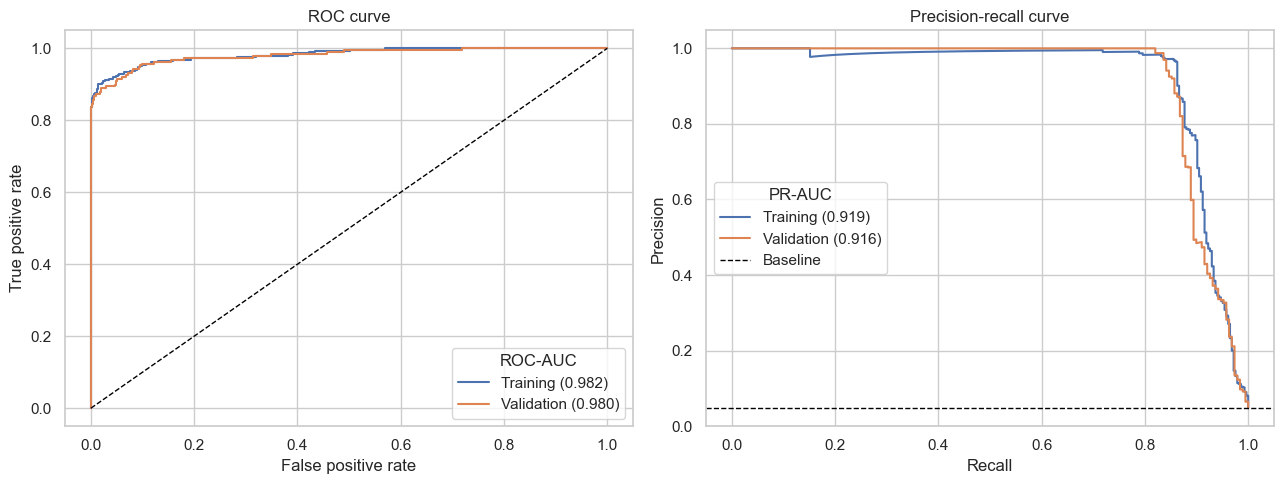

In [27]:
# plot training and validation discrimination curves
training_fpr, training_tpr, _ = roc_curve(
    training_predictions[TARGET_COLUMN], training_predictions["fraud_probability"]
)
validation_fpr, validation_tpr, _ = roc_curve(
    validation_predictions[TARGET_COLUMN], validation_predictions["fraud_probability"]
)
training_precision, training_recall, _ = precision_recall_curve(
    training_predictions[TARGET_COLUMN], training_predictions["fraud_probability"]
)
validation_precision, validation_recall, _ = precision_recall_curve(
    validation_predictions[TARGET_COLUMN], validation_predictions["fraud_probability"]
)

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(training_fpr, training_tpr, label=f"Training ({discrimination_results.loc['training', 'ROC-AUC']:.3f})")
axes[0].plot(validation_fpr, validation_tpr, label=f"Validation ({discrimination_results.loc['validation', 'ROC-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
axes[0].set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(title="ROC-AUC")

axes[1].plot(training_recall, training_precision, label=f"Training ({discrimination_results.loc['training', 'PR-AUC']:.3f})")
axes[1].plot(validation_recall, validation_precision, label=f"Validation ({discrimination_results.loc['validation', 'PR-AUC']:.3f})")
axes[1].axhline(validation_target.mean(), linestyle="--", color="black", linewidth=1, label="Baseline")
axes[1].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
axes[1].legend(title="PR-AUC")

figure.tight_layout()
figure.savefig("../reports/figures/logistic_discrimination_curves.png", dpi=160, bbox_inches="tight")
plt.show()

## Probability calibration

In [28]:
# measure probability error before selecting a cutoff
brier_results = pd.DataFrame({
    "Brier score": [
        brier_score_loss(training_predictions[TARGET_COLUMN], training_predictions["fraud_probability"]),
        brier_score_loss(validation_predictions[TARGET_COLUMN], validation_predictions["fraud_probability"]),
    ]
}, index=["training", "validation"])
display(brier_results)

,Brier score
training,0.0079
validation,0.0080


In [29]:
# compare validation probabilities with observed fraud by decile
validation_calibration = validation_predictions[[TARGET_COLUMN, "fraud_probability"]].copy()
validation_calibration["probability_decile"] = (
    pd.qcut(
        validation_calibration["fraud_probability"],
        q=10,
        labels=False,
        duplicates="drop",
    )
    + 1
)
calibration_table = (
    validation_calibration.groupby("probability_decile", observed=True)
    .agg(
        transactions=(TARGET_COLUMN, "size"),
        mean_probability=("fraud_probability", "mean"),
        observed_fraud_rate=(TARGET_COLUMN, "mean"),
    )
    .reset_index()
)
display(calibration_table)

,probability_decile,transactions,mean_probability,observed_fraud_rate
0,1,398,0.0004,0.0000
1,2,398,0.0009,0.0000
2,3,397,0.0015,0.0025
3,4,398,0.0020,0.0000
4,5,398,0.0028,0.0025
5,6,397,0.0038,0.0025
6,7,398,0.0051,0.0050
7,8,397,0.0077,0.0025
8,9,398,0.0151,0.0251
9,10,398,0.4291,0.4347


## Classification at the 0.50 cutoff

In [30]:
def evaluate_cutoff(predictions, cutoff):
    predicted_class = predictions["fraud_probability"].ge(cutoff).astype(int)
    actual_class = predictions[TARGET_COLUMN]
    return {
        "cutoff": cutoff,
        "accuracy": accuracy_score(actual_class, predicted_class),
        "precision": precision_score(actual_class, predicted_class, zero_division=0),
        "recall": recall_score(actual_class, predicted_class, zero_division=0),
        "F1": f1_score(actual_class, predicted_class, zero_division=0),
    }

# evaluate the conventional cutoff
REFERENCE_CUTOFF = 0.50
cutoff_050_results = pd.DataFrame(
    [
        evaluate_cutoff(training_predictions, REFERENCE_CUTOFF),
        evaluate_cutoff(validation_predictions, REFERENCE_CUTOFF),
    ],
    index=["training", "validation"],
)
cutoff_050_results

,cutoff,accuracy,precision,recall,F1
training,0.5000,0.9911,0.9753,0.8345,0.8994
validation,0.5000,0.9912,0.9873,0.8254,0.8991


In [31]:
# display classification errors at the reference cutoff
training_confusion_050 = pd.DataFrame(
    confusion_matrix(
        training_predictions[TARGET_COLUMN],
        training_predictions["fraud_probability"].ge(REFERENCE_CUTOFF),
    ),
    index=["actual normal", "actual fraud"],
    columns=["predicted normal", "predicted fraud"],
)
validation_confusion_050 = pd.DataFrame(
    confusion_matrix(
        validation_predictions[TARGET_COLUMN],
        validation_predictions["fraud_probability"].ge(REFERENCE_CUTOFF),
    ),
    index=["actual normal", "actual fraud"],
    columns=["predicted normal", "predicted fraud"],
)
confusion_tables_050 = pd.concat(
    {"training": training_confusion_050, "validation": validation_confusion_050},
    names=["sample", "actual"],
)
display(confusion_tables_050)

predicted normal  predicted fraud
sample     actual                                          
training   actual normal              5675                6
           actual fraud                 47              237
validation actual normal              3786                2
           actual fraud                 33              156

## OOF cutoff selection

In [32]:
# generate one unseen probability for each training observation
CUTOFF_FOLDS = 5
cutoff_cv = StratifiedKFold(
    n_splits=CUTOFF_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
logit_oof_predictions = training_data[[ROW_ID_COLUMN, TARGET_COLUMN]].copy()
logit_oof_predictions["fraud_probability"] = np.nan

for fold_training_positions, fold_holdout_positions in cutoff_cv.split(
    training_data, training_target
):
    fold_training_index = training_data.index[fold_training_positions]
    fold_holdout_index = training_data.index[fold_holdout_positions]

    fold_scaler = StandardScaler()
    fold_training_scaled = pd.DataFrame(
        fold_scaler.fit_transform(
            training_data.loc[fold_training_index, SELECTED_FEATURES]
        ),
        columns=SELECTED_FEATURES,
        index=fold_training_index,
    )
    fold_holdout_scaled = pd.DataFrame(
        fold_scaler.transform(
            training_data.loc[fold_holdout_index, SELECTED_FEATURES]
        ),
        columns=SELECTED_FEATURES,
        index=fold_holdout_index,
    )

    fold_model = sm.Logit(
        training_target.loc[fold_training_index],
        sm.add_constant(fold_training_scaled, has_constant="add"),
    ).fit(disp=False, maxiter=200)
    logit_oof_predictions.loc[
        fold_holdout_index, "fraud_probability"
    ] = fold_model.predict(
        sm.add_constant(fold_holdout_scaled, has_constant="add")
    )

assert logit_oof_predictions["fraud_probability"].notna().all()
assert np.isfinite(logit_oof_predictions["fraud_probability"]).all()
assert logit_oof_predictions["fraud_probability"].between(0, 1).all()

In [33]:
# maximize accuracy across all unique OOF probabilities
oof_probabilities = logit_oof_predictions["fraud_probability"].to_numpy()
oof_actual = logit_oof_predictions[TARGET_COLUMN].to_numpy()
candidate_cutoffs = np.unique(
    np.concatenate([
        oof_probabilities,
        [np.nextafter(oof_probabilities.max(), np.inf)],
    ])
)
cutoff_rows = []

for cutoff in candidate_cutoffs:
    predicted_class = oof_probabilities >= cutoff
    correct_observations = int((predicted_class == oof_actual).sum())
    cutoff_rows.append({
        "cutoff": cutoff,
        "correct_observations": correct_observations,
        "oof_accuracy": correct_observations / len(oof_actual),
    })

oof_cutoff_results = pd.DataFrame(cutoff_rows)
maximum_correct = oof_cutoff_results["correct_observations"].max()
best_cutoffs = oof_cutoff_results.loc[
    oof_cutoff_results["correct_observations"].eq(maximum_correct)
].sort_values("cutoff")
LOGISTIC_CUTOFF = float(best_cutoffs.iloc[0]["cutoff"])

top_cutoff_results = (
    oof_cutoff_results.sort_values(
        ["correct_observations", "cutoff"],
        ascending=[False, True],
    )
    .head(10)
    .reset_index(drop=True)
)
display(top_cutoff_results)

,cutoff,correct_observations,oof_accuracy
0,0.3121,5915,0.9916
1,0.2863,5914,0.9915
2,0.3210,5914,0.9915
3,0.2750,5913,0.9913
4,0.3970,5913,0.9913
5,0.2712,5912,0.9911
6,0.4031,5912,0.9911
7,0.2590,5911,0.9909
8,0.4122,5911,0.9909
9,0.5466,5911,0.9909


## Classification at the selected cutoff

In [34]:
# evaluate the locked cutoff without changing it on validation
selected_cutoff_results = pd.DataFrame(
    [
        evaluate_cutoff(logit_oof_predictions, LOGISTIC_CUTOFF),
        evaluate_cutoff(validation_predictions, LOGISTIC_CUTOFF),
    ],
    index=["OOF training", "validation"],
)
selected_cutoff_results

,cutoff,accuracy,precision,recall,F1
OOF training,0.3121,0.9916,0.9680,0.8521,0.9064
validation,0.3121,0.9907,0.9578,0.8413,0.8958


In [35]:
# display errors at the locked cutoff
oof_confusion_selected = pd.DataFrame(
    confusion_matrix(
        logit_oof_predictions[TARGET_COLUMN],
        logit_oof_predictions["fraud_probability"].ge(LOGISTIC_CUTOFF),
    ),
    index=["actual normal", "actual fraud"],
    columns=["predicted normal", "predicted fraud"],
)
validation_confusion_selected = pd.DataFrame(
    confusion_matrix(
        validation_predictions[TARGET_COLUMN],
        validation_predictions["fraud_probability"].ge(LOGISTIC_CUTOFF),
    ),
    index=["actual normal", "actual fraud"],
    columns=["predicted normal", "predicted fraud"],
)
selected_confusion_tables = pd.concat(
    {
        "OOF training": oof_confusion_selected,
        "validation": validation_confusion_selected,
    },
    names=["sample", "actual"],
)
display(selected_confusion_tables)

predicted normal  predicted fraud
sample       actual                                          
OOF training actual normal              5673                8
             actual fraud                 42              242
validation   actual normal              3781                7
             actual fraud                 30              159

## Export logistic results

The fixed split, full-sample predictions and out-of-fold training probabilities are saved for the model comparison notebook.

In [36]:
# save logistic outputs for the comparison notebook
logistic_model_predictions = pd.concat(
    [
        training_predictions.assign(**{SPLIT_COLUMN: SPLIT_CODES["training"]}),
        validation_predictions.assign(**{SPLIT_COLUMN: SPLIT_CODES["validation"]}),
    ],
    ignore_index=True,
)
logistic_oof_export = logit_oof_predictions[
    [ROW_ID_COLUMN, "fraud_probability"]
].rename(columns={"fraud_probability": "oof_fraud_probability"})
logistic_model_predictions = logistic_model_predictions.merge(
    logistic_oof_export,
    on=ROW_ID_COLUMN,
    how="left",
    validate="one_to_one",
).sort_values(ROW_ID_COLUMN).reset_index(drop=True)
logistic_model_predictions = logistic_model_predictions[
    [
        ROW_ID_COLUMN,
        TARGET_COLUMN,
        SPLIT_COLUMN,
        "fraud_probability",
        "oof_fraud_probability",
    ]
]

assert len(logistic_model_predictions) == len(fraud_data)
assert logistic_model_predictions[ROW_ID_COLUMN].is_unique
assert (
    logistic_model_predictions["oof_fraud_probability"].notna().sum()
    == len(training_data)
)
assert logistic_model_predictions.loc[
    logistic_model_predictions[SPLIT_COLUMN].eq(SPLIT_CODES["validation"]),
    "oof_fraud_probability",
].isna().all()

LOGISTIC_PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
logistic_model_predictions.to_csv(LOGISTIC_PREDICTIONS_PATH, index=False)
display(pd.Series({
    "rows saved": len(logistic_model_predictions),
    "output file": str(LOGISTIC_PREDICTIONS_PATH),
}, name="value").to_frame())

,value
rows saved,9942
output file,../data/processed/logistic_model_predictions.csv


## Conclusion

- The final logistic model retains `V4`, `V8`, `V10`, `V12`, `V14`, `V21`, `V22` and `V23`; all have p-values below 0.05, while the transformed `Amount` is not retained.
- Validation ROC-AUC is 0.9802 and PR-AUC is 0.9160, showing strong ranking performance on this modified sample.
- The five-fold OOF accuracy-maximizing cutoff is 0.3121. At this locked cutoff, validation accuracy is 0.9907, recall is 0.8413 and F1 is 0.8958.
- The validation Brier score is 0.0080, but calibration and the cutoff remain sample-specific because the normal class was undersampled.